# BART demo: `tree_ensembles.bart` on two TabReD datasets

What this notebook shows, for a regression task (**cooking-time**) and a binary
classification task (**homesite-insurance**):

1. fit / predict / predict_proba, compared with my default XGBoost;
2. uncertainty: posterior sd, predictive sd, and 95% HPDI intervals for f(x) and for a new y;
3. parameters: posterior mean, sd and 95% HPDI (e.g. the noise sd sigma);
4. MCMC convergence diagnostics (R-hat, ESS, trace and rank plots);
5. what the trees look like: depth, leaves, which features and cut values they use.

Runtime on a laptop CPU is a few minutes with the sizes below. BART's cost grows with
rows x trees x iterations for fitting, and with test rows x draws x trees for predicting.

In [1]:
# Must run before anything uses JAX: lets the 4 MCMC chains run in parallel on CPU.
import jax

jax.config.update("jax_num_cpu_devices", 4)

In [2]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from tree_ensembles.bart import BartClassifier, BartRegressor
from tree_ensembles.bart.plots import plot_rank, plot_trace, plot_tree_sizes, plot_variable_usage
from tree_ensembles.tree_plot import plot_tree, plot_trees
from tree_ensembles.xgb import XGBDefaultClassifier, XGBDefaultRegressor

DATA_DIR = Path(os.environ.get("TREE_ENSEMBLES_DATA", "../data"))
N_TRAIN = 20_000  # training rows sampled from the default split (None = all, ~225k)
N_TEST = 5_000  # test rows sampled (None = all)
BART_SETTINGS = dict(num_trees=200, n_burn=500, n_save=500, num_chains=4, show_progress=False)

%config InlineBackend.figure_format = "retina"  # figures at 2x resolution, sharp on HiDPI screens

In [3]:
DATA_DIR

PosixPath('../data')

## Data

Each TabReD folder has numeric (`x_num`), binary (`x_bin`) and categorical (`x_cat`, integer
codes) features, `y`, and train/val/test splits. The categorical codes are loaded as pandas
`category` columns:

- BART has no categorical splits (bartz splits every column at numeric cutpoints), so
  `BartRegressor` / `BartClassifier` replace each level by its partially pooled mean of y,
  learned from the training rows (`order_categories=True`, the default). This orders similar
  levels next to each other, so one split can separate low-y levels from high-y ones.
- XGBoost splits `category` columns natively (`enable_categorical=True`).

A binary 0/1 feature works as is in both: its only cutpoint is 0.5.

**Missing values.** bartz accepts NaN but bins it poorly: every NaN counts as a distinct value
when cutpoints are chosen, which crowds out real cutpoints and creates splits that do nothing
(reported to bartz). Until that is fixed, `BartRegressor` / `BartClassifier` handle NaN
themselves: they median-impute (medians from the training rows) and add a 0/1 `<name>_missing`
column for every feature missing in more than 50% of the training rows, so the trees can split
on missingness (`impute_strategy`, `missing_indicator_threshold`). XGBoost handles NaN natively,
so both models get the same raw data.

In [4]:
def load_tabred(name, n_train=N_TRAIN, n_test=N_TEST, seed=0):
    """Train/test features and targets from a TabReD folder (default split)."""
    folder = DATA_DIR / name
    blocks = []
    for kind in ["num", "bin", "cat"]:
        path = folder / f"x_{kind}.npy"
        if path.exists():
            values = np.load(path)
            names = [f"{kind}_{j}" for j in range(values.shape[1])]
            # categorical codes become pandas `category` columns, numbers become floats
            dtype = "category" if kind == "cat" else np.float32
            blocks.append(pd.DataFrame(values, columns=names).astype(dtype))
    X = pd.concat(blocks, axis=1)
    y = np.load(folder / "y.npy")

    rng = np.random.default_rng(seed)

    def rows(split, n):
        idx = np.load(folder / "splits" / "default" / f"{split}.npy")
        return np.sort(rng.choice(idx, n, replace=False)) if n and n < len(idx) else idx

    train, test = rows("train", n_train), rows("test", n_test)
    return (
        X.iloc[train].reset_index(drop=True),
        y[train],
        X.iloc[test].reset_index(drop=True),
        y[test],
    )

## Part 1. Regression: cooking-time

### Fit and compare with XGBoost

In [5]:
X_train, y_train, X_test, y_test = load_tabred("cooking-time")
print("columns with NaN:", int(X_train.isna().any().sum()), "of", X_train.shape[1])
print("columns missing in > 50% of rows:", int((X_train.isna().mean() > 0.5).sum()))
print("train", X_train.shape, "test", X_test.shape)

columns with NaN: 56 of 192
columns missing in > 50% of rows: 5
train (20000, 192) test (5000, 192)


In [6]:
start = time.time()
reg = BartRegressor(**BART_SETTINGS).fit(X_train, y_train)  # imputes NaN itself
bart_pred = reg.predict(X_test)  # posterior mean of f(x); also waits for the MCMC to finish
print(f"BART fit + predict: {time.time() - start:.0f}s")
print("missing indicators added by BART:", len(reg.model_feature_names_) - X_train.shape[1])

xgb_reg = XGBDefaultRegressor().fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)


def rmse(pred):
    return np.sqrt(np.mean((pred - y_test) ** 2))


print(f"test RMSE  BART {rmse(bart_pred):.4f}   XGBoost {rmse(xgb_pred):.4f}")

BART fit + predict: 48s
missing indicators added by BART: 5


test RMSE  BART 0.4836   XGBoost 0.4861


How BART ordered the levels of a categorical feature: `n` rows per level, their mean y,
the `weight` given to the level's own mean (1 = its own mean, 0 = fully pooled toward the
overall mean), and the resulting `pooled_mean`, which replaces the level in the trees. Levels
with few rows are pulled toward the overall mean.

In [7]:
levels = reg.category_encoder_.levels_["cat_0"]
print({k: round(v, 4) for k, v in levels.attrs.items()})  # mu, sigma2, tau2
levels

{'mu': 2.5263, 'sigma2': 0.3482, 'tau2': 0.1381}


,n,mean_y,weight,pooled_mean
level,,,,
5,822,1.889758,0.996942,1.891705
1,1256,1.955730,0.997997,1.956873
3,1407,2.288047,0.998211,2.288473
0,4320,2.289440,0.999417,2.289578
2,508,2.295893,0.995062,2.297031
4,443,2.630522,0.994341,2.629933
6,11244,2.763763,0.999776,2.763709


### Uncertainty for each test row

- `predict_dist`: posterior **mean** of f(x), its posterior **sd** (how unsure the model is about
  the mean), and the **predictive sd** of a new y at x, which also includes the noise:
  `predictive_sd² = sd² + E[sigma²]`.
- `predict_interval(kind="mean")`: credible interval for **f(x)**, the average y at x.
- `predict_interval(kind="predictive")`: interval for **a new observation y**. It is much wider,
  and it is the one that should cover about 95% of the actual test values.

In [8]:
dist = reg.predict_dist(X_test)
dist.head()

,mean,sd,predictive_sd
0,1.999650,0.080446,0.463680
1,2.674225,0.112574,0.470320
2,2.686518,0.082973,0.464125
3,3.210324,0.123558,0.473069
4,2.600018,0.095257,0.466478


In [9]:
mean_ci = reg.predict_interval(X_test, prob=0.95, kind="mean")
pred_ci = reg.predict_interval(X_test, prob=0.95, kind="predictive")


def coverage(ci):
    return np.mean((y_test >= ci["lower"]) & (y_test <= ci["upper"]))


pd.DataFrame(
    {
        "share of test y inside": [coverage(mean_ci), coverage(pred_ci)],
        "average width": [
            (mean_ci.upper - mean_ci.lower).mean(),
            (pred_ci.upper - pred_ci.lower).mean(),
        ],
    },
    index=["95% HPDI of f(x)", "95% predictive HPDI of y"],
)

,share of test y inside,average width
95% HPDI of f(x),0.3084,0.362437
95% predictive HPDI of y,0.9338,1.809649


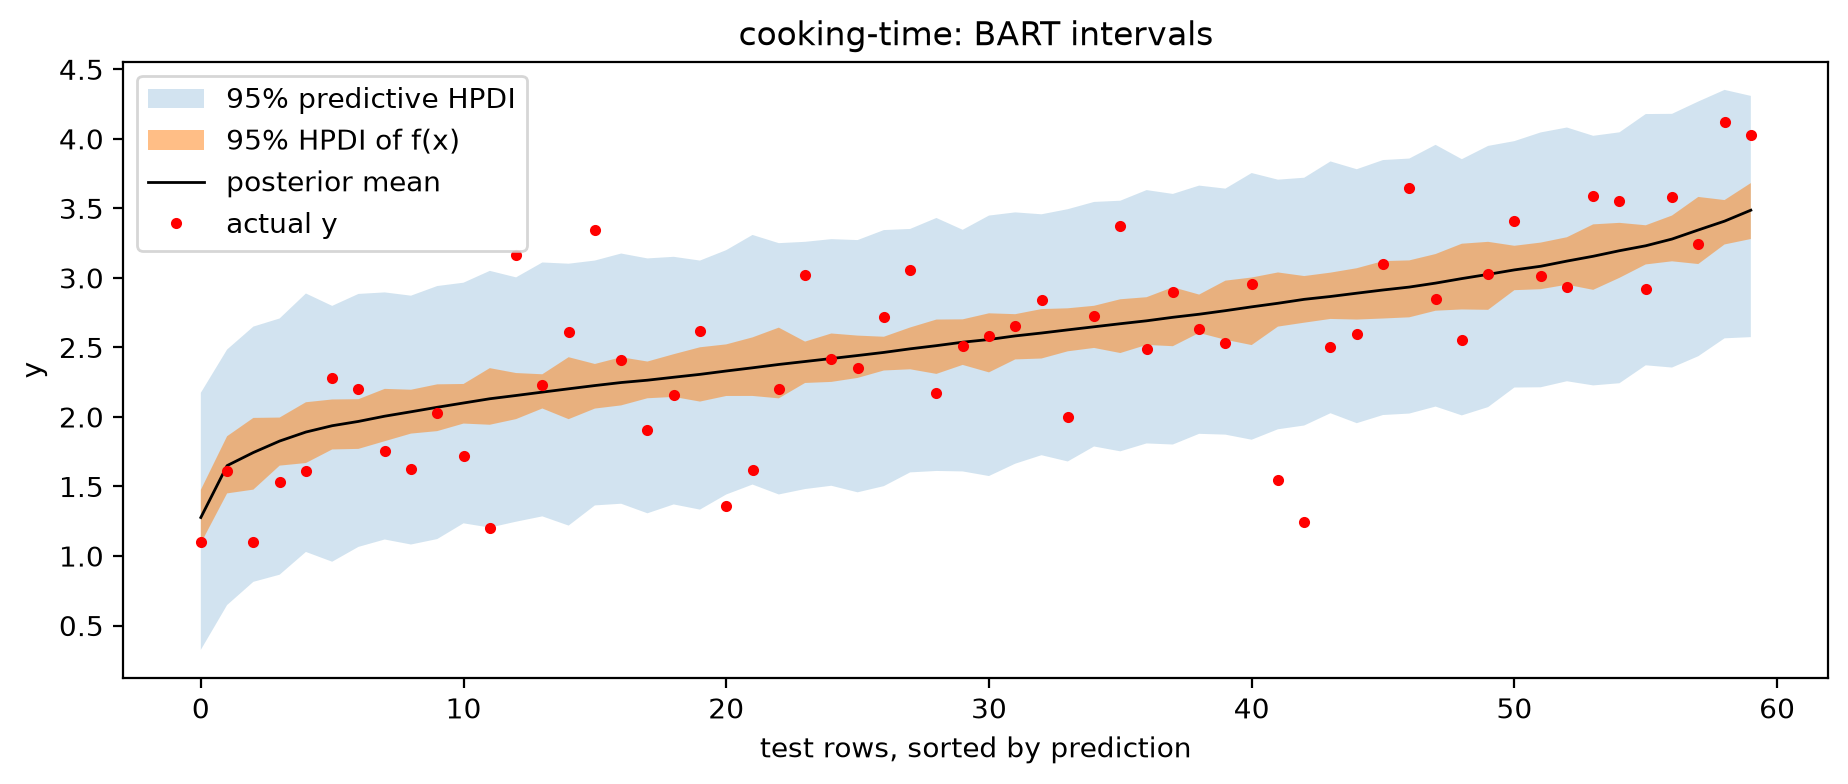

In [10]:
show = np.argsort(bart_pred)[:: len(bart_pred) // 60][:60]  # 60 rows spread over the range
x = np.arange(len(show))
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(x, pred_ci.lower[show], pred_ci.upper[show], alpha=0.2, label="95% predictive HPDI")
ax.fill_between(x, mean_ci.lower[show], mean_ci.upper[show], alpha=0.5, label="95% HPDI of f(x)")
ax.plot(x, bart_pred[show], "k-", lw=1, label="posterior mean")
ax.plot(x, y_test[show], "r.", label="actual y")
ax.set(xlabel="test rows, sorted by prediction", ylabel="y", title="cooking-time: BART intervals")
ax.legend(loc="upper left");

`predict_samples(X)` returns the raw posterior draws (one row per draw, one column per test row),
in case you want a quantity the methods above do not compute, e.g. P(f(x) > 3):

In [11]:
draws = reg.predict_samples(X_test[:5])  # shape (n_draws, 5): 4 chains x 500 draws
print(draws.shape)
print("P(f(x) > 3) for the first 5 test rows:", (draws > 3).mean(axis=0).round(3))

(2000, 5)
P(f(x) > 3) for the first 5 test rows: [0.    0.    0.    0.975 0.   ]


### Parameters: posterior summary (95% HPDI)

`sigma` is the noise sd. `mean_tree_leaves` / `mean_tree_depth` summarize the size of the trees in
each draw. R-hat and ESS tell whether these numbers can be trusted (next section).

In [12]:
reg.posterior_summary()

,mean,sd,hpdi_0.95_low,hpdi_0.95_high,rhat,ess_bulk,ess_tail,ok
name,,,,,,,,
sigma,0.456642,0.002352,0.45193,0.461022,1.029127,125.162650,913.711677,False
mean_tree_leaves,2.418715,0.053830,2.31500,2.525000,1.035656,111.514325,180.442075,False
mean_tree_depth,1.367450,0.048668,1.26000,1.450000,1.038810,115.495069,392.193740,False


### Convergence diagnostics

`diagnostics()` adds **f(x) at 20 training rows**: the model's
prediction at 20 fixed rows, tracked across draws. When fitting, the model keeps a *copy* of 20
random training rows for this; they are not held out, and the model is fit on all training rows.
They check that the *predictions* have converged, not only the global parameters. You can pass
any rows instead, e.g. test rows, with `diagnostics(X_probe=X_test[:50])`.

Rule of thumb (Vehtari et al. 2021): R-hat < 1.01 and bulk/tail ESS > 400. In BART, sigma and
the tree size often mix slowly; the fix is a longer `n_burn` / `n_save` or more chains.

The 20 points are summarized in two rows: `f(x_probe): median` (the typical point) and
`f(x_probe): worst` (largest R-hat, smallest ESS); `diagnostics(per_point=True)` lists every
point, and `diag.attrs["f_ok_share"]` is the share of points that pass.

Two more rows are reported but not checked for convergence:

- `accept_rate`: the average share of trees with an accepted grow / prune move.
- `leaf_fill`: the mean number of leaves per tree out of the most that `maxdepth` allows
  (`diag.attrs["max_leaves"]`, 32 for `maxdepth=6`). It is the "leaves 2.6/32" in bartz's
  progress bar, as a share (0.081). BART works best with many *small* trees. If this
  number creeps up, each tree is doing a lot of the fitting: use more trees. `diagnostics`
  warns above `leaf_fill_max=0.25` (8 of 32 leaves).

In [13]:
diag = reg.diagnostics()
print(f"probe rows passing: {diag.attrs['f_ok_share']:.0%}")
print(f"leaves per tree: {diag.loc['mean_tree_leaves', 'mean']:.1f}/{diag.attrs['max_leaves']}")
diag[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]

probe rows passing: 0%
leaves per tree: 2.4/32


/var/folders/z6/6gqdsxwx6blf3zqz985_x_b40000gn/T/ipykernel_62652/1303243909.py:1: UserWarning: Possible lack of convergence for: ['sigma', 'mean_tree_leaves', 'mean_tree_depth', 'f(x) at 20 of 20 probe rows']
  diag = reg.diagnostics()


,mean,rhat,ess_bulk,ess_tail,ok
name,,,,,
sigma,0.456642,1.029127,125.162650,913.711677,False
mean_tree_leaves,2.418715,1.035656,111.514325,180.442075,False
mean_tree_depth,1.367450,1.038810,115.495069,392.193740,False
accept_rate,0.312102,NaN,NaN,NaN,<NA>
leaf_fill,0.075585,NaN,NaN,NaN,<NA>
f(x_probe): median,NaN,1.262786,11.628497,38.419785,False
f(x_probe): worst,NaN,1.657088,6.426381,12.258879,False


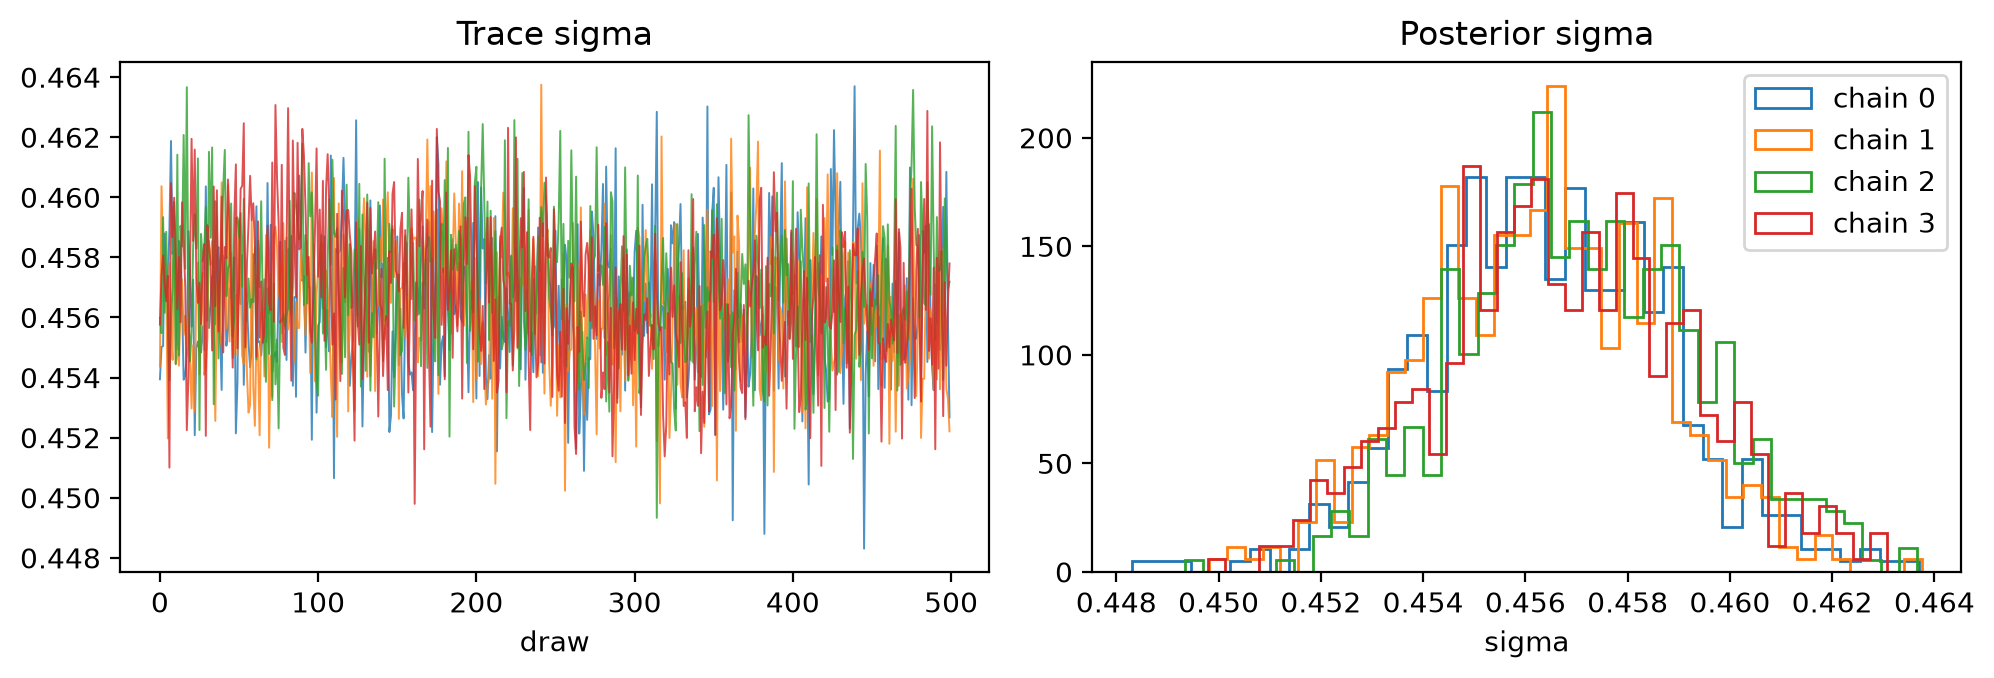

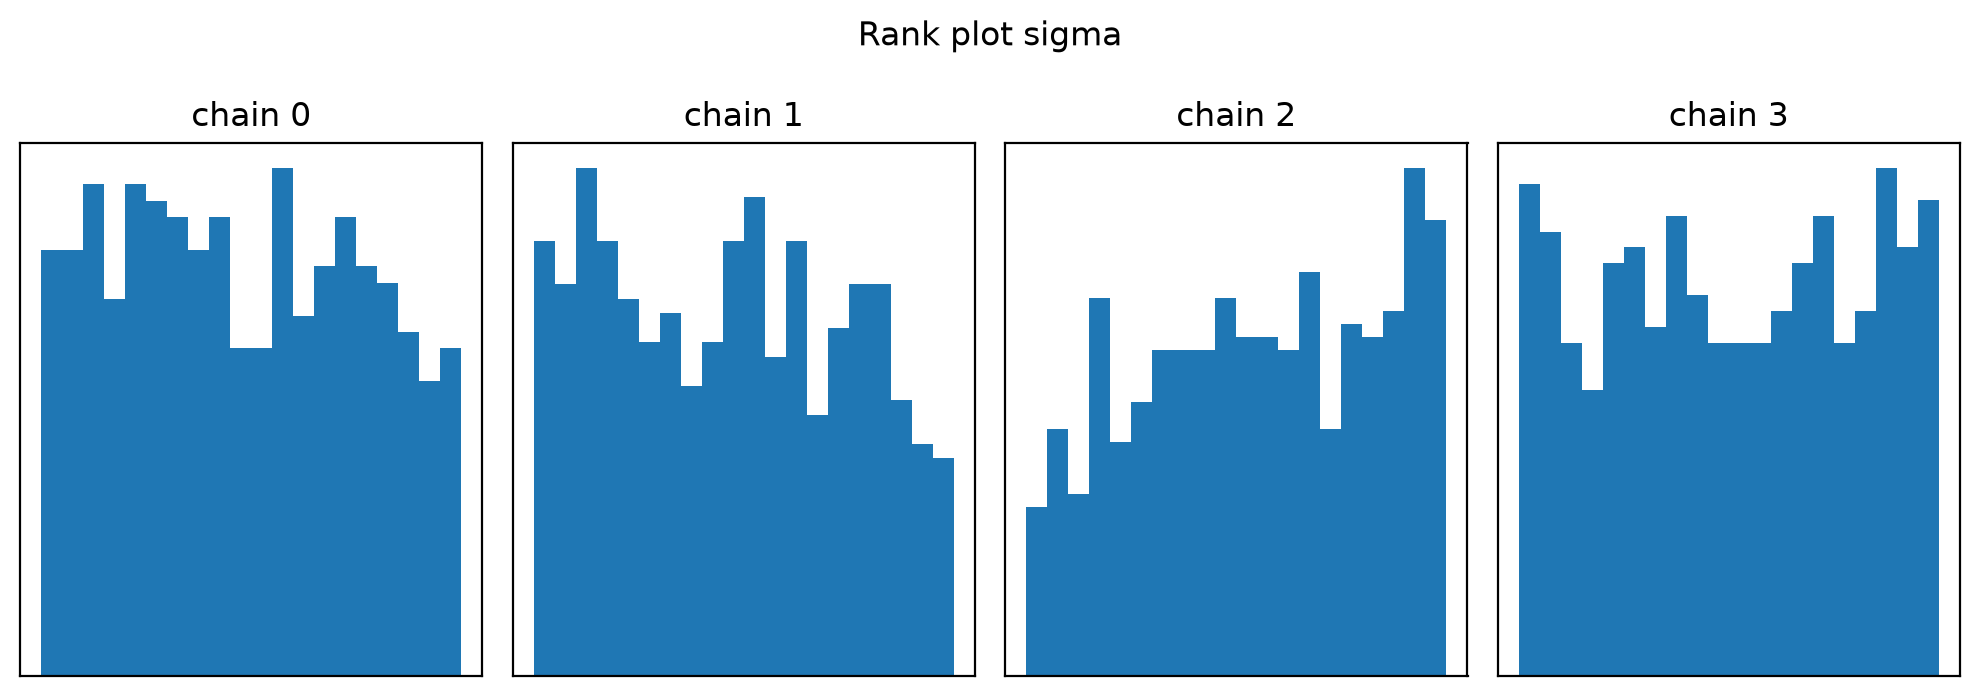

In [14]:
params = reg.parameter_draws()  # each (chain, draw)
plot_trace(params["sigma"], "sigma")
plot_rank(params["sigma"], "sigma");

**Reading these results.** With these short demo chains, sigma is close to converged, but the
tree size and f(x) at single rows are flagged: the 4 chains disagree (R-hat well above 1.01) and
the ESS is tiny. This is real, not a bug (the numbers match ArviZ), and longer chains help only
slowly: on this data, 2,000 burn-in + 1,000 draws per chain still gave R-hat about 1.5 for some
f(x). BART is known to mix slowly for large n, because the trees rarely restructure once grown.

What this means in practice:

- The **predictions** (posterior mean) are still good, as the RMSE above shows; pooling 4 chains
  also averages over the different places the chains got stuck.
- The **intervals** may be too narrow or too wide, because each chain explores only part of the
  posterior. Check the predictive coverage on held-out data (as above, against the 95% target).
- How to improve mixing: see the next section.

### Improving MCMC convergence

What helps BART mix, roughly from most to least useful for the "chains disagree about f(x)"
problem seen above:

- **More trees** (`num_trees`). With more trees each one contributes less (the leaf prior
  shrinks as the number of trees grows), so a single tree can change a lot without hurting the
  fit: more moves are accepted and f moves faster. Cost grows about linearly with the number of
  trees; accuracy usually changes little. `leaf_fill` in `diagnostics()` shows when the trees
  are getting large, a sign that more trees are needed.
- **More chains** (`num_chains`). Pooled chains cover more of the posterior, and on CPU they run
  in parallel (`jax_num_cpu_devices` at the top).
- **A sparse prior on the features** (DART, `sparse=SparseConfig()`, Linero 2018). Splits
  concentrate on the features that matter, which shrinks the space the sampler has to explore,
  and the posterior splitting probabilities show which features it keeps.
- **Fewer or coarser cutpoints**, e.g.
  `binner=functools.partial(bartz.prepcovars.UniqueQuantileBinner, max_bins=64)`: fewer,
  larger moves to choose from.
- **Longer runs** (`n_burn`, `n_save`, `n_skip`). These add draws, but chains stuck in
  different places stay stuck for a long time, so they help R-hat least.
- **Warm starts** from a fast greedy fit (the grow-from-root / XBART approach of `stochtree`)
  help a lot in published comparisons, but bartz does not offer them.

Below, the same data and settings with 200 trees (the model above), 800 trees, and DART with
200 trees.

In [15]:
import warnings

from bartz import SparseConfig


def fit_and_check(name, **settings):
    """Fit BART with BART_SETTINGS changed by `settings`; summarize accuracy and convergence."""
    start = time.time()
    model = BartRegressor(**{**BART_SETTINGS, **settings}).fit(X_train, y_train)
    pred = model.predict(X_test)  # also waits for the MCMC to finish
    seconds = time.time() - start
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # the table shows what fails
        diag = model.diagnostics()
    row = {
        "model": name,
        "seconds": seconds,
        "test RMSE": rmse(pred),
        "sigma R-hat": diag.loc["sigma", "rhat"],
        "tree size R-hat": diag.loc["mean_tree_leaves", "rhat"],
        "f(x) median R-hat": diag.loc["f(x_probe): median", "rhat"],
        "f(x) worst R-hat": diag.loc["f(x_probe): worst", "rhat"],
        "f(x) median ESS": diag.loc["f(x_probe): median", "ess_bulk"],
        "probe rows passing": diag.attrs["f_ok_share"],
        "accept rate": diag.loc["accept_rate", "mean"],
        "leaves per tree": diag.loc["mean_tree_leaves", "mean"],
        "leaf fill": diag.loc["leaf_fill", "mean"],
    }
    return row, model


baseline, _ = fit_and_check("200 trees (as above)")
more_trees, _ = fit_and_check("800 trees", num_trees=800)
dart_row, dart = fit_and_check("DART, 200 trees", sparse=SparseConfig())
pd.DataFrame([baseline, more_trees, dart_row]).set_index("model").round(3)

,seconds,test RMSE,sigma R-hat,tree size R-hat,f(x) median R-hat,f(x) worst R-hat,f(x) median ESS,probe rows passing,accept rate,leaves per tree,leaf fill
model,,,,,,,,,,,
200 trees (as above),43.555,0.484,1.029,1.036,1.263,1.657,11.628,0.0,0.312,2.419,0.076
800 trees,294.797,0.482,1.067,1.044,1.138,1.350,23.806,0.0,0.373,2.409,0.075
"DART, 200 trees",48.761,0.482,1.030,1.077,1.292,1.597,10.605,0.0,0.311,2.472,0.077


Which features DART keeps: its posterior splitting probability per feature (summing to 1
over all features), with a 95% HPDI. Features it does not need get probabilities near 0.

In [16]:
dart_importance = dart.variable_importance()
print(
    "features with split_prob above 1 / p:",
    int((dart_importance["split_prob"] > 1 / len(dart_importance)).sum()),
    "of",
    len(dart_importance),
)
dart_importance[["split_prob", "split_prob_low", "split_prob_high", "split_share"]].round(4).head(
    10
)

features with split_prob above 1 / p: 42 of 197


,split_prob,split_prob_low,split_prob_high,split_share
feature,,,,
num_184,0.1954,0.0877,0.3034,0.2130
num_133,0.0860,0.0418,0.1326,0.0933
num_80,0.0558,0.0162,0.0991,0.0602
num_131,0.0329,0.0000,0.0666,0.0356
num_52,0.0212,0.0002,0.0565,0.0227
num_69,0.0203,0.0004,0.0460,0.0217
num_165_missing,0.0209,0.0000,0.0978,0.0211
num_130,0.0178,0.0005,0.0413,0.0193
num_28,0.0180,0.0000,0.0513,0.0192


**Reading the comparison.** None of the three converges by the strict standard (no probe row
passes), and accuracy is the same for all (test RMSE about 0.48):

- **800 trees** helps clearly, but at a high price: the median R-hat of f(x) falls from about
  1.26 to 1.14, the worst from about 1.66 to 1.35, the ESS doubles and more moves are accepted.
  The cost grows at least in proportion to the number of trees (the time also includes
  compiling for the new size). More trees help, but you need many more, not 50% more.
- **Tree size** (`leaf fill`) is about 2.4 of 32 possible leaves per tree for all three, close to
  the prior's 2.5: the trees are already small, so here the reason to add trees is mixing, not
  tree size. A `leaf fill` that grows well above the prior's (`diagnostics` warns above 0.25) is
  the other sign that more trees are needed.
- **DART** concentrates the splits on a few dozen of the ~200 features (`split_prob` above) and
  is about as fast, but here it does not mix better: on this data the slow part is how the trees
  carve up the feature space, not which features they use. Its value is the variable selection.
- For dependable intervals on large data, combine more trees and more chains, and check the
  held-out coverage of `predict_interval`.

### What the trees look like

Every draw has 200 trees. Most BART trees are small (1-3 splits): the fit is a sum of many weak
trees. Variable usage counts how often each feature is used to split, averaged over draws.

share of trees by depth:
0    0.082
1    0.560
2    0.276
3    0.073
4    0.008
5    0.001


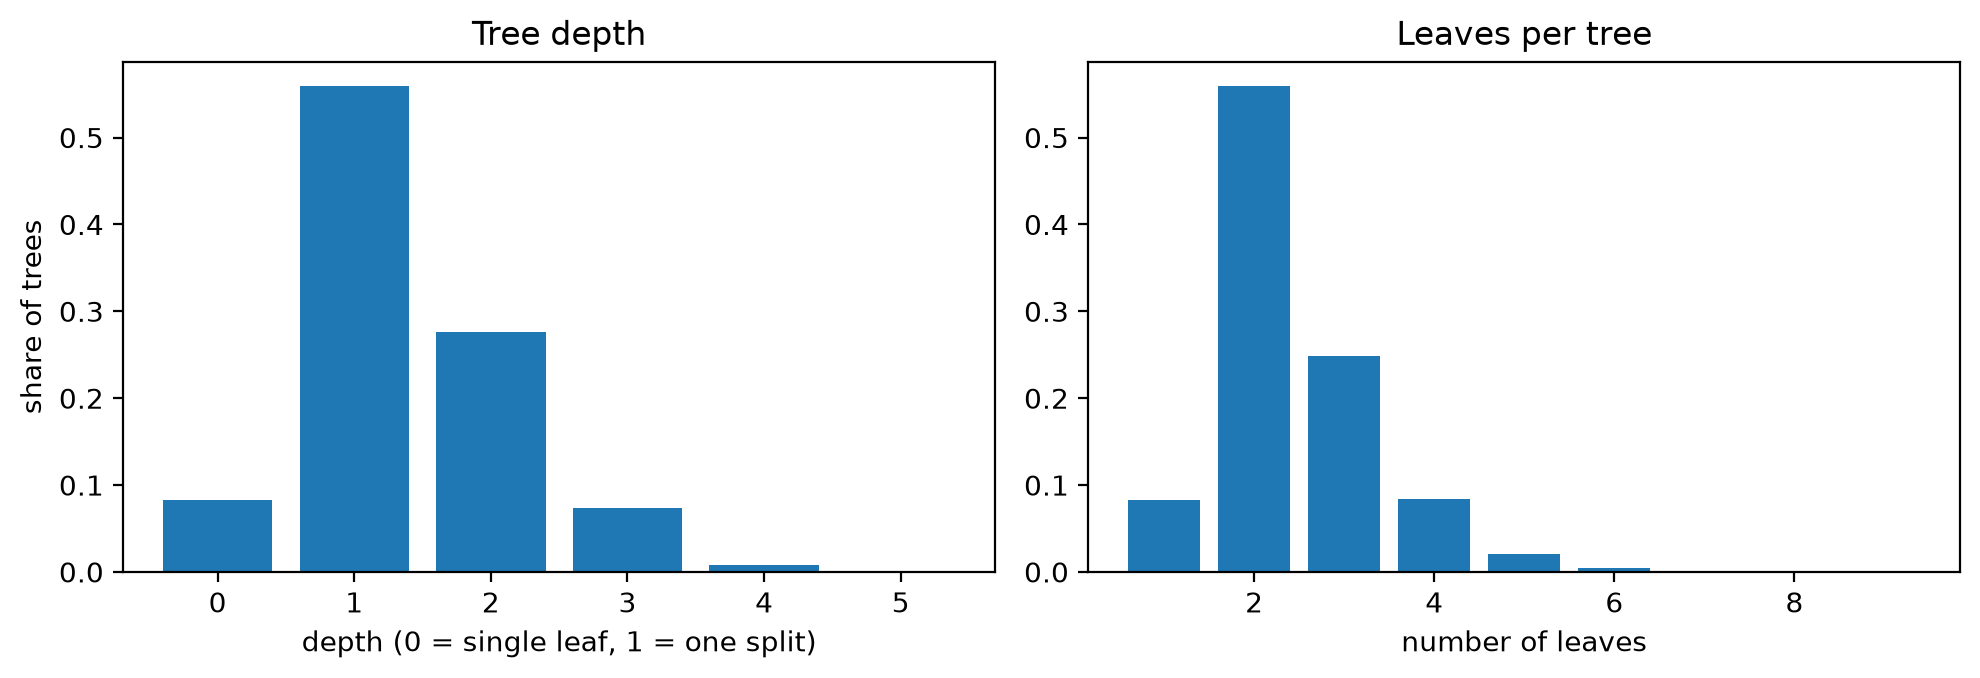

In [17]:
forest = reg.forest_summary()
print("share of trees by depth:")
print(forest.depth_distribution().round(3).to_string())
plot_tree_sizes(forest);

,mean_splits_per_draw,share_of_splits
feature,,
num_184,10.6825,0.037649
num_133,10.1535,0.035784
num_80,5.4825,0.019322
num_130,4.1895,0.014765
num_131,3.7340,0.013160
num_42,3.4070,0.012007
cat_0,3.2305,0.011385
num_52,3.1000,0.010925
bin_0,2.9065,0.010243


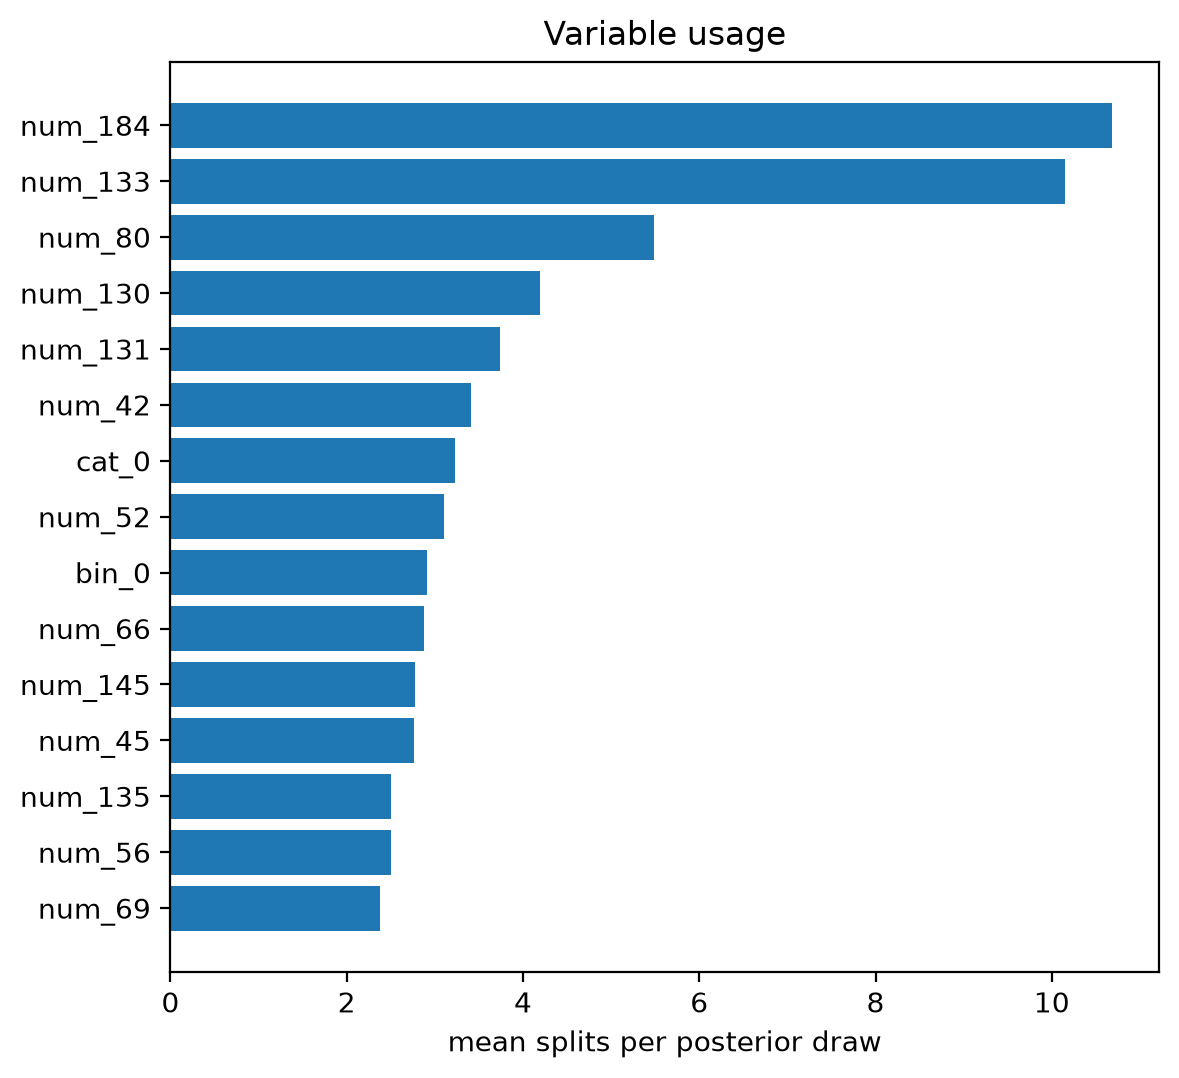

In [18]:
plot_variable_usage(forest, top=15)
forest.variable_usage().head(10)

In [19]:
reg.split_points().head(10)  # most used cut values (a row goes right if x > cutpoint)

,feature,cutpoint,count
0,bin_0,0.500000,5813
1,bin_1,0.500000,4429
2,num_165_missing,0.500000,4322
3,cat_2,2.500457,3806
4,num_168_missing,0.500000,3371
5,num_167_missing,0.500000,3346
6,num_166_missing,0.500000,3227
7,num_169_missing,0.500000,2949
8,cat_1,2.608217,1943
9,bin_2,0.500000,1851


### Variable importance with uncertainty

`variable_importance` computes several measures per posterior draw, so each has a mean and a
95% HPDI (`_low`, `_high`):

- `split_share`: share of the splits that use the feature (the count above, as a share);
- `inclusion_prob`: share of draws that use the feature at all (near 1 with 200 trees);
- `row_share`: splits weighted by the rows of `X` they divide (like XGBoost's cover);
- `gain_share`: share of the variation of the fitted f(x) that comes from splits on the
  feature, from the trees' own predictions on `X` (not a likelihood gain).

A feature split often in small corners ranks high on `split_share` but low on `gain_share`.

In [20]:
importance = reg.variable_importance(X_test)
shown = ["split_share", "row_share", "row_share_low", "row_share_high"]
shown += ["gain_share", "gain_share_low", "gain_share_high"]
importance[shown].round(3).head(10)

,split_share,row_share,row_share_low,row_share_high,gain_share,gain_share_low,gain_share_high
feature,,,,,,,
num_184,0.038,0.043,0.029,0.057,0.088,0.063,0.112
num_133,0.036,0.041,0.029,0.050,0.083,0.058,0.113
num_80,0.019,0.023,0.013,0.032,0.042,0.016,0.076
bin_0,0.010,0.010,0.000,0.021,0.036,0.000,0.115
cat_0,0.011,0.013,0.004,0.021,0.034,0.000,0.108
bin_1,0.008,0.008,0.000,0.018,0.029,0.000,0.095
num_130,0.015,0.017,0.007,0.026,0.027,0.009,0.045
num_52,0.011,0.012,0.004,0.021,0.025,0.002,0.054
num_42,0.012,0.013,0.004,0.024,0.021,0.000,0.042


`interactions` counts how often two features split as parent and child (one feature used
only on one side of the other's cut), per draw:

In [21]:
reg.interactions().head(10)

,feature_a,feature_b,mean_per_draw,share
0,num_2,num_184,0.5140,0.005164
1,num_49,num_133,0.3965,0.003983
2,num_2,num_80,0.3720,0.003737
3,num_21,bin_1,0.3290,0.003305
4,num_69,bin_0,0.3130,0.003144
5,num_133,num_184,0.2950,0.002964
6,num_184,num_165_missing,0.2935,0.002949
7,num_8,num_133,0.2925,0.002939
8,num_98,num_133,0.2850,0.002863
9,num_105,num_184,0.2815,0.002828


In [22]:
# one sampled tree with at least 3 splits
tree = int(np.argmax(forest.n_splits[0, -1] >= 3))
print(reg.format_tree(chain=0, draw=reg.n_save - 1, tree=tree))

if bin_1 <= 0.5:
    if num_21 <= -0.7089:
        if num_151 <= 0.0241:
            leaf -0.0475
        else:  # num_151 > 0.0241 or missing
            leaf +0.05533
    else:  # num_21 > -0.7089 or missing
        leaf +0.07134
else:  # bin_1 > 0.5 or missing
    leaf -0.1194


### The trees as a table, and tree plots

`trees_to_dataframe` lists every node of the selected trees, like XGBoost's
`Booster.trees_to_dataframe`: the split (`feature`, `cutpoint`, `condition`, children,
`missing` direction) or the leaf value, plus `num_rows` (rows of `X` reaching the node) when
`X` is given. Here: all 200 trees of the last draw of chain 0, with rows counted on the
test rows. A draw's prediction is the offset plus the sum of the leaves a row reaches.

In [23]:
table = reg.trees_to_dataframe(chains=0, draws=-1, X=X_test)
print(table.shape)
table.head(8)

(794, 14)


,chain,draw,tree,node,depth,is_leaf,feature,cutpoint,condition,left,right,missing,leaf_value,num_rows
0,0,499,0,1,0,False,num_135,-0.870654,num_135 <= -0.8707,2,3,None,NaN,5000
1,0,499,0,2,1,True,NaN,NaN,NaN,<NA>,<NA>,None,0.011962,878
2,0,499,0,3,1,True,NaN,NaN,NaN,<NA>,<NA>,None,0.047061,4122
3,0,499,1,1,0,False,num_166_missing,0.500000,num_166_missing <= 0.5,2,3,None,NaN,5000
4,0,499,1,2,1,False,num_107,0.807896,num_107 <= 0.8079,4,5,None,NaN,52
5,0,499,1,3,1,True,NaN,NaN,NaN,<NA>,<NA>,None,-0.033523,4948
6,0,499,1,4,2,True,NaN,NaN,NaN,<NA>,<NA>,None,0.032767,28
7,0,499,1,5,2,True,NaN,NaN,NaN,<NA>,<NA>,None,-0.037414,24


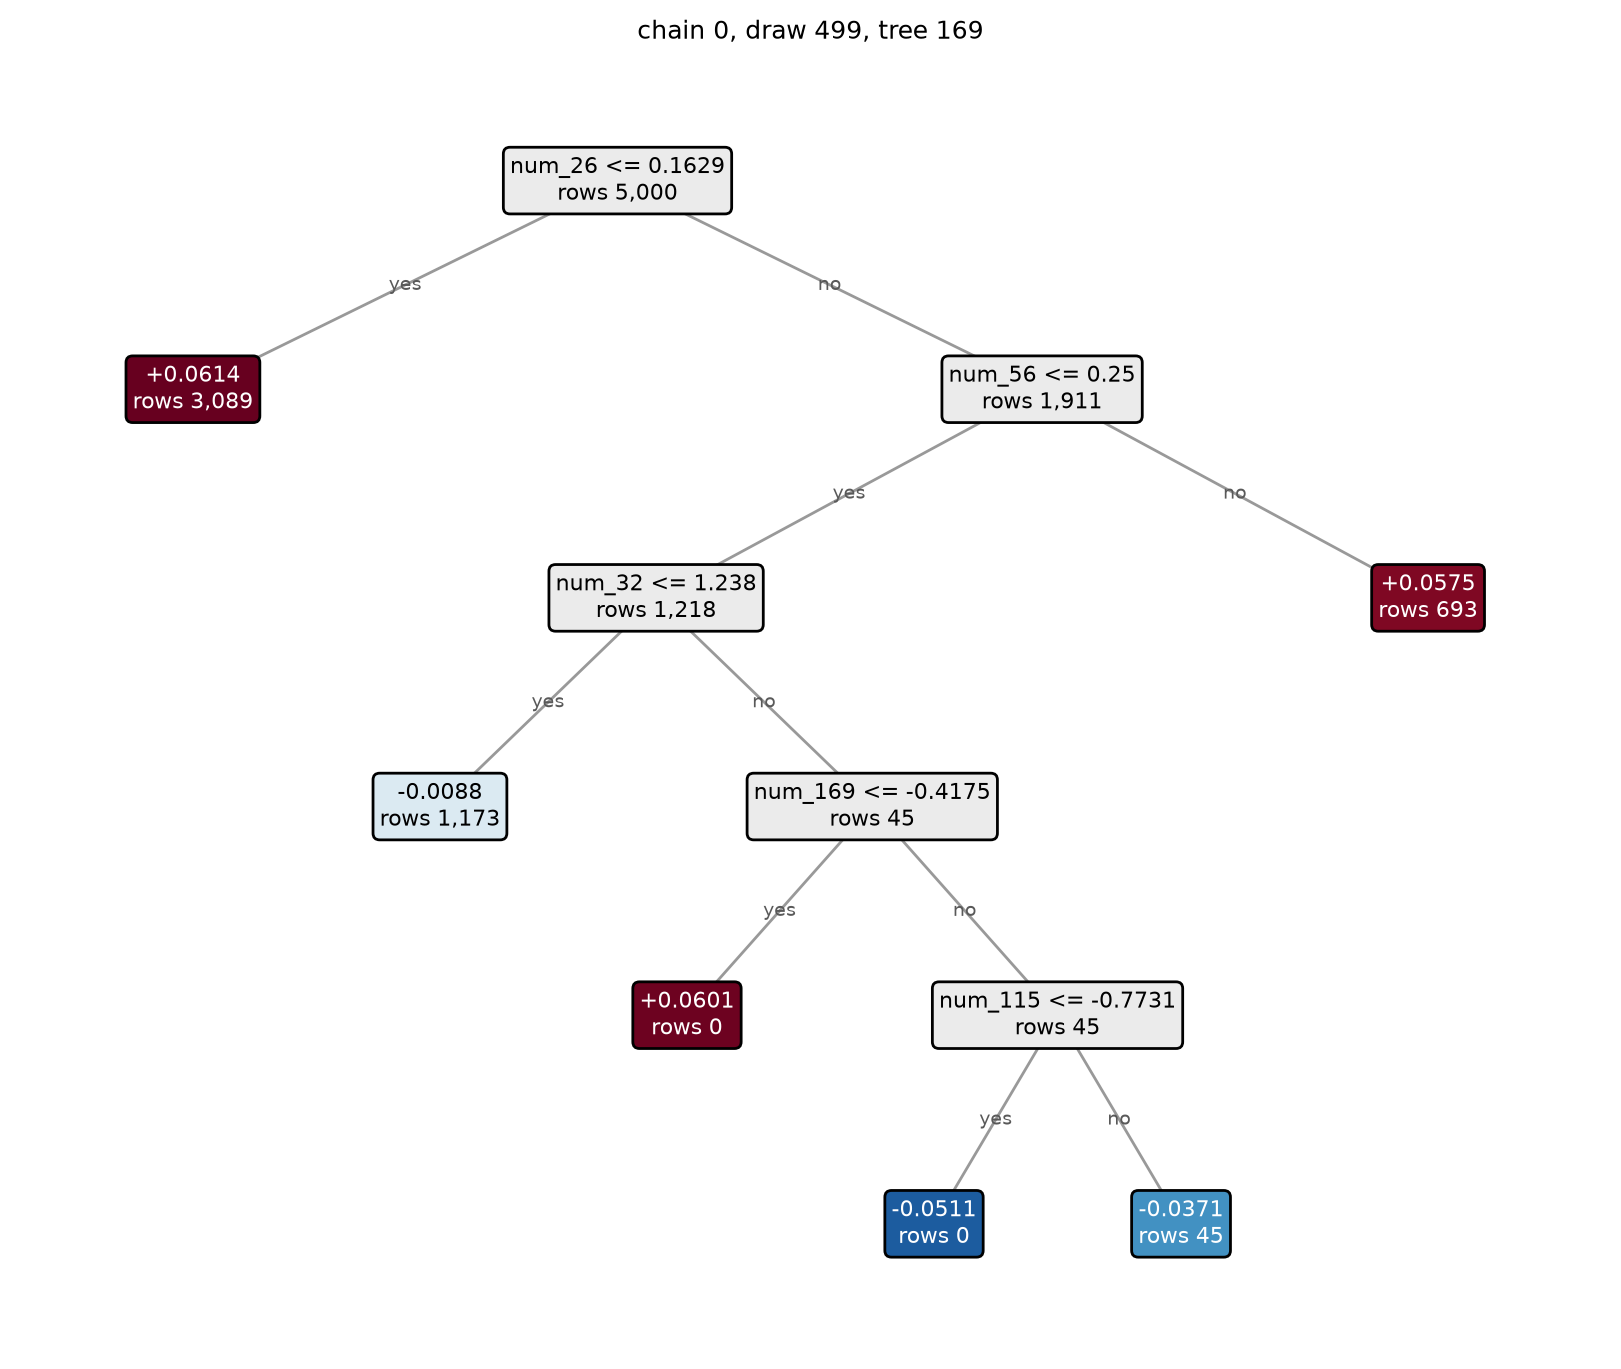

In [24]:
# the largest tree of that draw
splits_per_tree = table[~table["is_leaf"]].groupby("tree").size()
plot_tree(table[table["tree"] == splits_per_tree.idxmax()]);

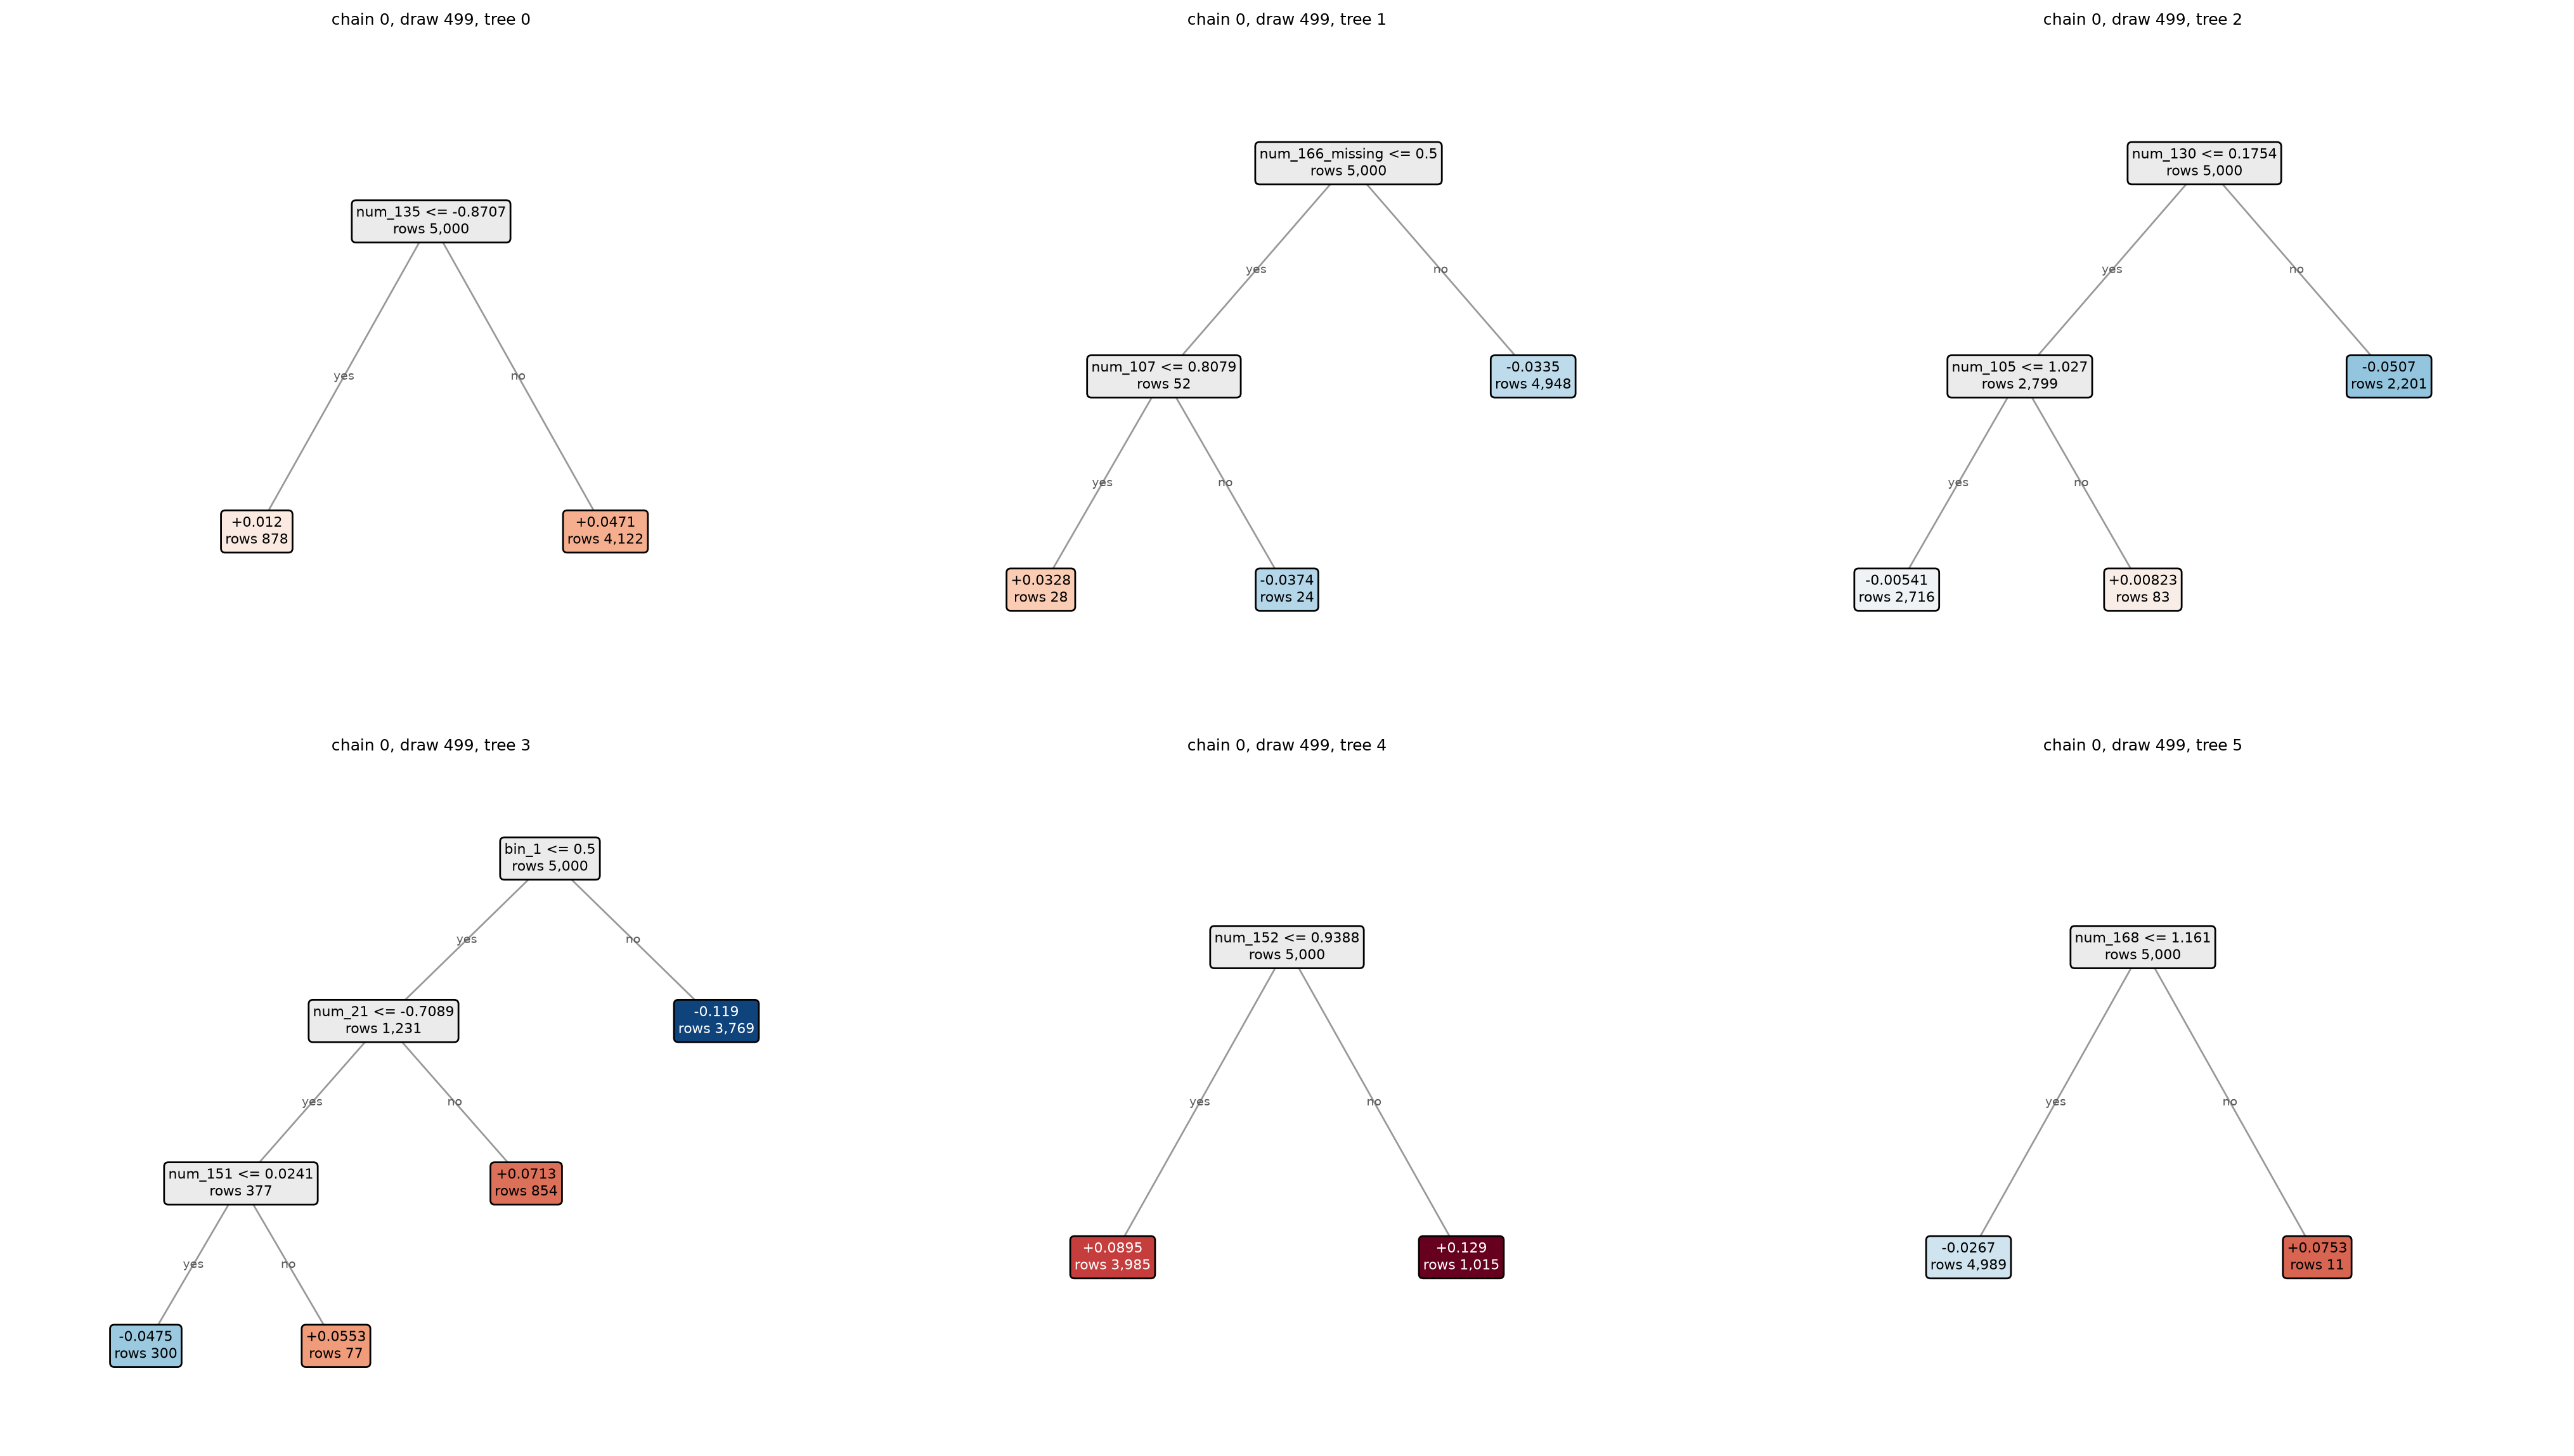

In [25]:
# the first 6 trees, with one color scale for the leaf values
plot_trees(table[table["tree"] < 6], ncols=3);

The same table and plots work for XGBoost. Its trees are much deeper, so `max_depth`
draws only the top levels ("..." marks where a tree continues). XGBoost splits read
`x < cut` (BART: `x <= cut`), and its node size is `cover`, the sum of the hessians of the training rows (equal to the
row count here, for squared error).

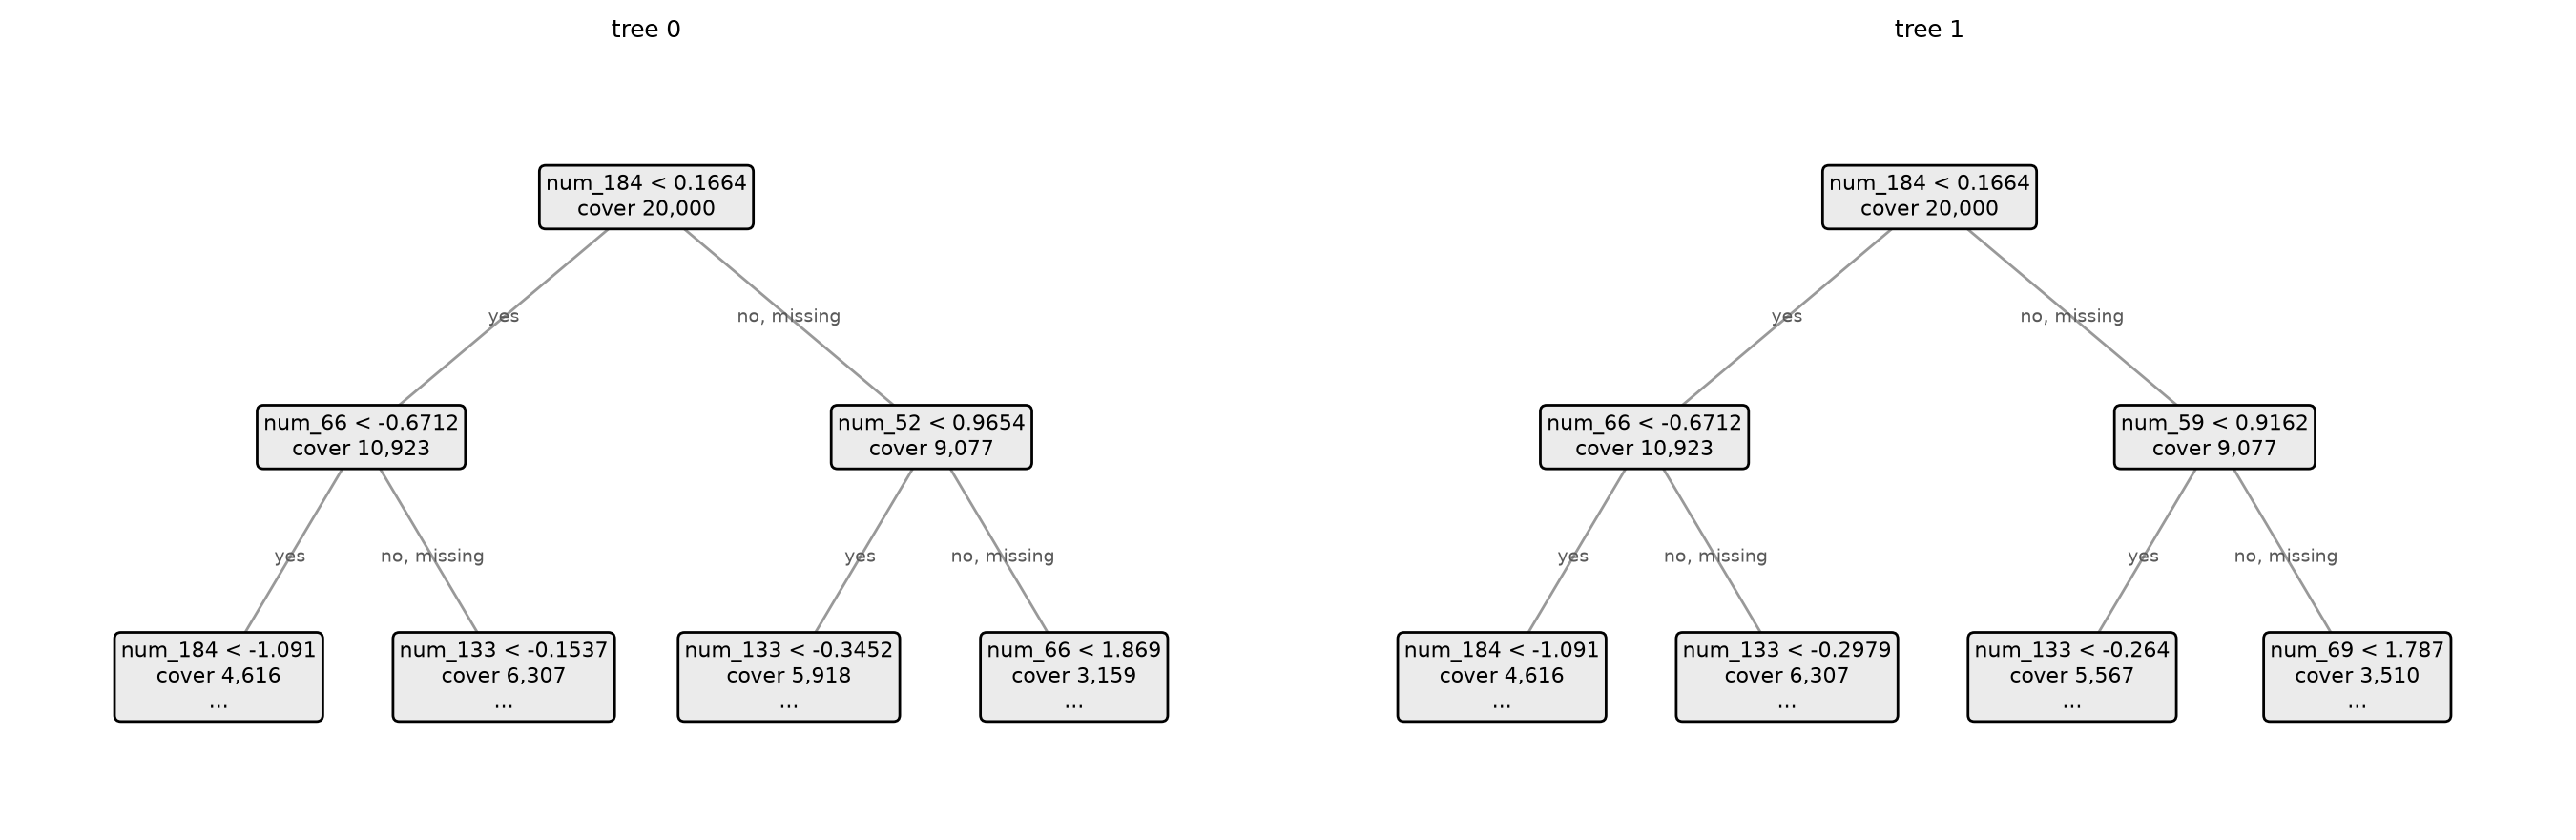

In [26]:
xgb_table = xgb_reg.trees_to_dataframe(trees=[0, 1])
plot_trees(xgb_table, ncols=2, max_depth=2);

## Part 2. Classification: homesite-insurance

`BartClassifier` is **probit** BART: P(y = 1 | x) = Phi(f(x)). There is no noise sd sigma; the
intervals are for the probability p(x).

In [27]:
X_train, y_train, X_test, y_test = load_tabred("homesite-insurance")
print("columns with NaN:", int(X_train.isna().any().sum()), "of", X_train.shape[1])
print("columns missing in > 50% of rows:", int((X_train.isna().mean() > 0.5).sum()))
print("train", X_train.shape, "test", X_test.shape, "share of y = 1:", y_train.mean().round(3))

columns with NaN: 70 of 299
columns missing in > 50% of rows: 1
train (20000, 299) test (5000, 299) share of y = 1: 0.185


In [28]:
start = time.time()
clf = BartClassifier(**BART_SETTINGS).fit(X_train, y_train)  # imputes NaN itself
bart_proba = clf.predict_proba(X_test)[:, 1]
print(f"BART fit + predict: {time.time() - start:.0f}s")
print("missing indicators added by BART:", len(clf.model_feature_names_) - X_train.shape[1])

xgb_clf = XGBDefaultClassifier().fit(X_train, y_train)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
bart_auc, xgb_auc = roc_auc_score(y_test, bart_proba), roc_auc_score(y_test, xgb_proba)
print(f"test AUC  BART {bart_auc:.4f}   XGBoost {xgb_auc:.4f}")

BART fit + predict: 47s
missing indicators added by BART: 1


test AUC  BART 0.9520   XGBoost 0.9538


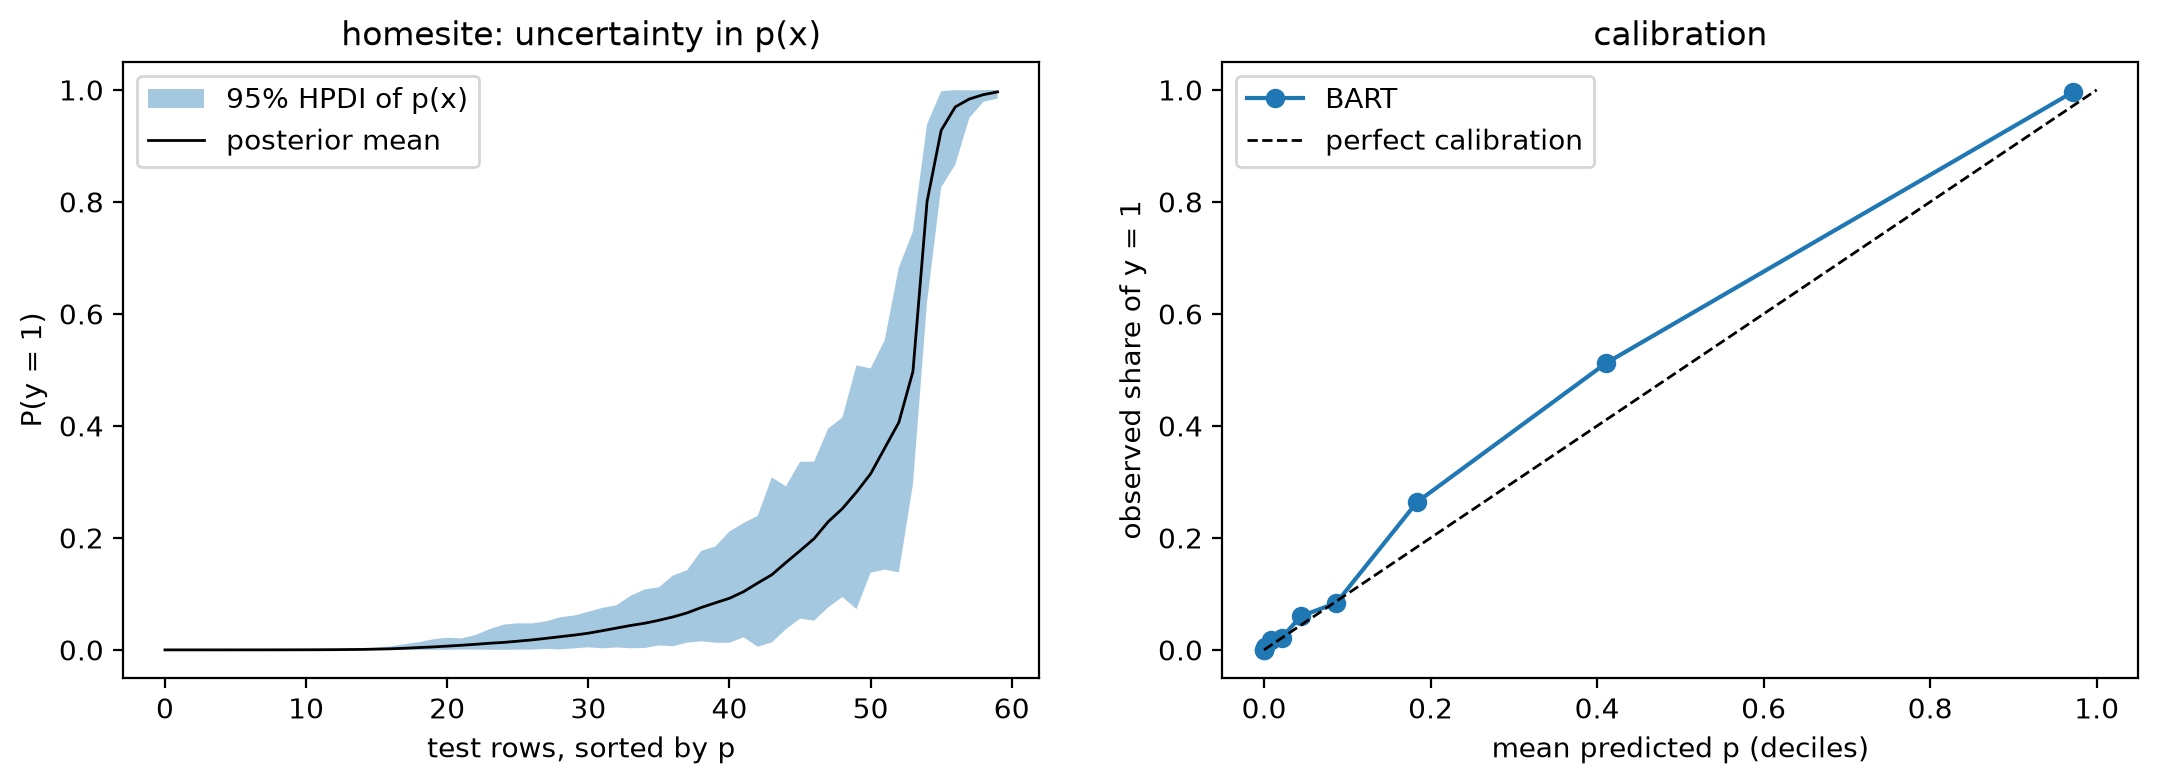

In [29]:
p_ci = clf.predict_interval(X_test, prob=0.95)  # 95% HPDI of p(x)
show = np.argsort(bart_proba)[:: len(bart_proba) // 60][:60]
x = np.arange(len(show))
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.fill_between(x, p_ci.lower[show], p_ci.upper[show], alpha=0.4, label="95% HPDI of p(x)")
left.plot(x, bart_proba[show], "k-", lw=1, label="posterior mean")
left.set(xlabel="test rows, sorted by p", ylabel="P(y = 1)", title="homesite: uncertainty in p(x)")
left.legend(loc="upper left")

bins = pd.qcut(bart_proba, 10, duplicates="drop")
calib = pd.DataFrame({"p": bart_proba, "y": y_test}).groupby(bins, observed=True).mean()
right.plot(calib["p"], calib["y"], "o-", label="BART")
right.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
right.set(
    xlabel="mean predicted p (deciles)", ylabel="observed share of y = 1", title="calibration"
)
right.legend();

In [30]:
clf.posterior_summary()

,mean,sd,hpdi_0.95_low,hpdi_0.95_high,rhat,ess_bulk,ess_tail,ok
name,,,,,,,,
mean_tree_leaves,2.572020,0.063402,2.46,2.705,1.157984,19.027645,112.126062,False
mean_tree_depth,1.504338,0.054648,1.41,1.620,1.164097,17.970135,95.343517,False


In [31]:
clf.diagnostics()[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]

/var/folders/z6/6gqdsxwx6blf3zqz985_x_b40000gn/T/ipykernel_62652/861839358.py:1: UserWarning: Possible lack of convergence for: ['mean_tree_leaves', 'mean_tree_depth', 'f(x) at 20 of 20 probe rows']
  clf.diagnostics()[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]


,mean,rhat,ess_bulk,ess_tail,ok
name,,,,,
mean_tree_leaves,2.572020,1.157984,19.027645,112.126062,False
mean_tree_depth,1.504338,1.164097,17.970135,95.343517,False
accept_rate,0.299400,NaN,NaN,NaN,<NA>
leaf_fill,0.080376,NaN,NaN,NaN,<NA>
f(x_probe): median,NaN,1.320357,10.487443,46.508506,False
f(x_probe): worst,NaN,1.603976,6.820583,15.426639,False


,mean_splits_per_draw,share_of_splits
feature,,
num_36,9.6180,0.030591
bin_11,8.1900,0.026049
bin_3,6.3735,0.020272
bin_4,5.7055,0.018147
num_41,5.3640,0.017061
num_40,5.1905,0.016509
num_23,4.9555,0.015762
num_133_missing,4.4835,0.014260
num_0,3.5955,0.011436


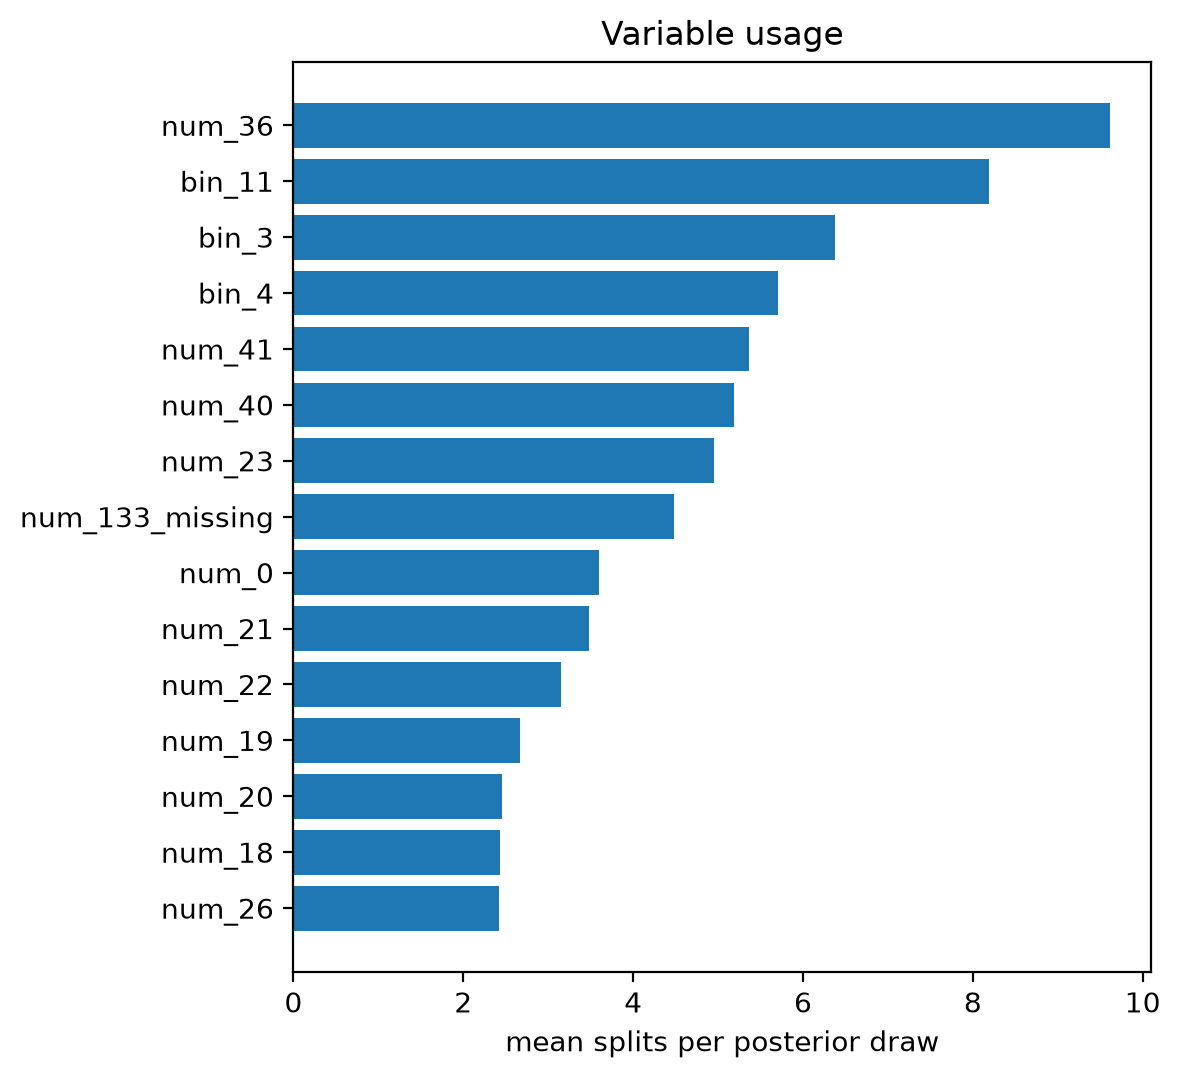

In [32]:
forest = clf.forest_summary()
plot_variable_usage(forest, top=15)
forest.variable_usage().head(10)

## Notes

- **Scaling up.** Set `N_TRAIN = None` and more trees / draws on a GPU (e.g. Colab). Predicting is
  test rows x draws x trees: for many test rows, use fewer saved draws (`n_save`) or batch rows.
- **Convergence first.** Check `diagnostics()` before trusting intervals; increase `n_burn` /
  `n_save` or `num_chains` when rows are flagged.
- **Saving.** `reg.dump("folder")` / `BartRegressor().load("folder")` use bartz's version-tied format:
  fine for caching, not for archiving.